Load Data

In [ ]:
import pandas as pd

features = pd.read_csv("HAZARD_CLUSTER_TABLE.csv")

feature_cols = [col for col in features.columns if col not in ["hazard_id", "cluster"]]

X = features[feature_cols]
y = features["cluster"]

print("Number of hazards:", len(features))
print("Clusters:", y.unique())

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

Train Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,      # number of trees
    max_depth=10,          # limit depth to reduce overfitting
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",  # important for unequal clusters
    random_state=42
)

rf.fit(X_train, y_train)

Evaluate Model

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Feature Importance

In [ ]:
import numpy as np

importances = rf.feature_importances_
sorted_importances = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

print("Feature Importance Ranking:\n")
for name, score in sorted_importances:
    print(f"{name}: {score:.3f}")

Plot Feature Importance

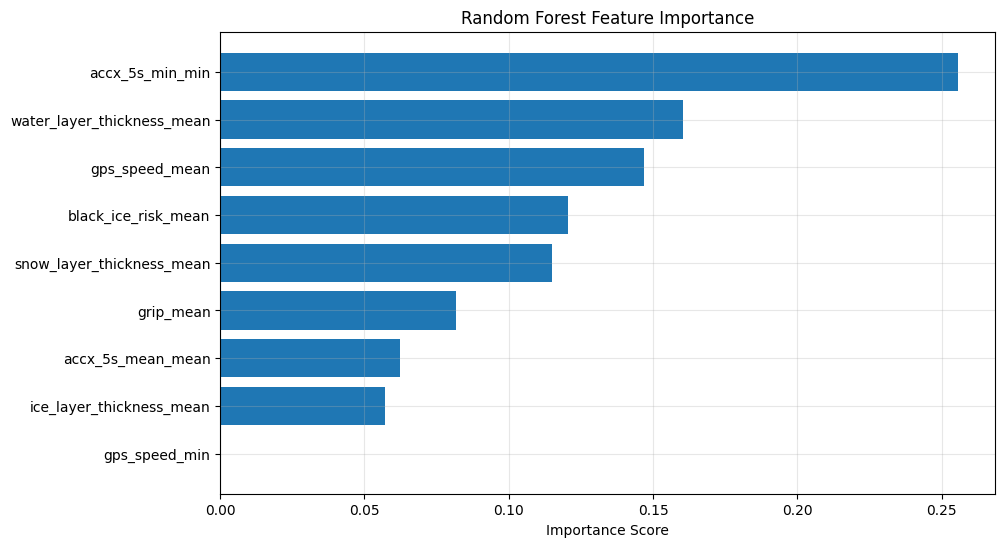

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
importance_df = pd.DataFrame(sorted_importances, columns=["Feature", "Importance"])

plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.grid(alpha=0.3)
plt.show()